In [1]:
using Pkg
Pkg.activate("/global/homes/j/jgmorawe/emulators_pipeline")

  Activating project at `~/emulators_pipeline`


In [2]:
using Effort
using AbstractCosmologicalEmulators
using PyCall
using Plots
using NPZ
using DelimitedFiles
using DataInterpolations

In [3]:
# Loads the different emulator components (monopole, quadrupole, hexadecapole)
home_dir = "/global/homes/j/jgmorawe/emulators_pipeline"
FS_emu_mono = Effort.load_multipole_emulator(home_dir * "/trained_effort_velocileptors_rept_mnuw0wacdm_50000/0/")
FS_emu_quad = Effort.load_multipole_emulator(home_dir * "/trained_effort_velocileptors_rept_mnuw0wacdm_50000/2/")
FS_emu_hexa = Effort.load_multipole_emulator(home_dir * "/trained_effort_velocileptors_rept_mnuw0wacdm_50000/4/")

PℓEmulator(ComponentEmulator(LuxEmulator(Lux.Chain{@NamedTuple{layer_1::Lux.Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_2::Lux.Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_3::Lux.Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_4::Lux.Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_5::Lux.Dense{typeof(identity), Int64, Int64, Nothing, Nothing, Static.True}}, Nothing}((layer_1 = Dense(9 => 32, tanh), layer_2 = Dense(32 => 32, tanh), layer_3 = Dense(32 => 32, tanh), layer_4 = Dense(32 => 32, tanh), layer_5 = Dense(32 => 165)), nothing), (layer_1 = (weight = Float32[0.12866618 0.06616345 … -0.15187398 -0.10081121; 0.0049915174 -0.074732184 … -0.508055 -0.21988599; … ; -0.18027411 0.051960334 … -0.41924295 -0.23864757; 0.08730349 -0.026820734 … -0.43762022 -0.055745557], bias = Float32[-0.16850919, 0.5436207, 0.12790033, 0.30755758, 0.1170085, 0.6245116, -0.12678763, 0.48402265, -1.0324254

In [4]:
# Functions to calculate theory vector

function theory_FS(effort_cosmo, eft_params_eulerian, z, D, kin)
    """Computes the stacked monopole/quadrupole/hexadecapole (with AP applied) given cosmological and EFT parameters."""
    emulator_input = [z, effort_cosmo.ln10Aₛ, effort_cosmo.nₛ, effort_cosmo.h*100, effort_cosmo.ωb, effort_cosmo.ωc,
                      effort_cosmo.mν, effort_cosmo.w0, effort_cosmo.wa]
    q_par, q_perp = Effort.q_par_perp(z, effort_cosmo, effort_cosmo_fid)
    pk0 = Effort.get_Pℓ(emulator_input, D, eft_params_eulerian, FS_emu_mono)
    pk2 = Effort.get_Pℓ(emulator_input, D, eft_params_eulerian, FS_emu_quad)
    pk4 = Effort.get_Pℓ(emulator_input, D, eft_params_eulerian, FS_emu_hexa)
    pk0_AP, pk2_AP, pk4_AP = Effort.apply_AP(vec(FS_emu_mono.P11.kgrid), kin, pk0, pk2, pk4, q_par, q_perp)
    return vcat(pk0_AP, pk2_AP, pk4_AP)
end

function theory_FS_noAP(effort_cosmo, eft_params_eulerian, z, D, kin)
    """Computes the stacked monopole/quadrupole/hexadecapole (with no AP applied) given cosmological and EFT parameters."""
    emulator_input = [z, effort_cosmo.ln10Aₛ, effort_cosmo.nₛ, effort_cosmo.h*100, effort_cosmo.ωb, effort_cosmo.ωc,
                      effort_cosmo.mν, effort_cosmo.w0, effort_cosmo.wa]
    q_par, q_perp = Effort.q_par_perp(z, effort_cosmo, effort_cosmo_fid)
    pk0 = Effort.get_Pℓ(emulator_input, D, eft_params_eulerian, FS_emu_mono)
    pk2 = Effort.get_Pℓ(emulator_input, D, eft_params_eulerian, FS_emu_quad)
    pk4 = Effort.get_Pℓ(emulator_input, D, eft_params_eulerian, FS_emu_hexa)
    pk0_noAP = CubicSpline(pk0, vec(FS_emu_mono.P11.kgrid)).(kin)
    pk2_noAP = CubicSpline(pk2, vec(FS_emu_mono.P11.kgrid)).(kin)
    pk4_noAP = CubicSpline(pk4, vec(FS_emu_mono.P11.kgrid)).(kin)
    return vcat(pk0_noAP, pk2_noAP, pk4_noAP)
end

# The 'output' theory vector which DESI uses (different from the emulator grid)
desi_kin = vec(readdlm("/global/homes/j/jgmorawe/emulators_pipeline/desi_kin.txt"))

349-element Vector{Float64}:
 0.001
 0.002
 0.003
 0.004
 0.005
 0.006
 0.007
 0.008
 0.009000000000000001
 0.010000000000000002
 0.011
 0.012
 0.013000000000000001
 ⋮
 0.338
 0.339
 0.34
 0.341
 0.342
 0.343
 0.34400000000000003
 0.34500000000000003
 0.34600000000000003
 0.34700000000000003
 0.34800000000000003
 0.34900000000000003

In [5]:
# Uses a test set of cosmological and EFT parameters
z, ln10As, ns, H0, ombh2, omch2, Mnu, w0, wa = 0.9, 2.8, 1.02, 59, 0.0235, 0.15, 0.06, -0.7, -0.9
emulator_input = [z, ln10As, ns, H0, ombh2, omch2, Mnu, w0, wa]
eft_params_eulerian = [2, -3, 3, 1, 30, 12, 0.2, 0, 0, 0, 0] # b1, b2, bs, b3, alpha0, alpha2, alpha4, alpha6, st0, st2, st4

# Initiates the effort cosmology for it, as well as the fiducial model (for purposes of computing AP later)
effort_cosmo = Effort.w0waCDMCosmology(ln10Aₛ=ln10As, nₛ=ns, h=H0/100, ωb=ombh2, ωc=omch2, mν=Mnu, w0=w0, wa=wa, ωk=0)
effort_cosmo_fid = Effort.w0waCDMCosmology(ln10Aₛ=3.044, nₛ=0.9649, h=0.6736, ωb=0.02237, ωc=0.12, mν=0.06, w0=-1, wa=0, ωk=0)

# Computes linear growth factor 
D = Effort.D_z(z, effort_cosmo)

0.5060139171685171

In [6]:
# Function to apply AP (in Python)
PyCall.py"""def q_par_perp(z, cosmo, cosmo_ref):
    q_par = (cosmo_ref.Hubble(z)/cosmo_ref.Hubble(0))/(cosmo.Hubble(z)/cosmo.Hubble(0))
    q_perp = (cosmo.angular_distance(z)*cosmo.Hubble(0))/(cosmo_ref.angular_distance(z)*cosmo_ref.Hubble(0))
    return [q_par, q_perp]
"""

In [7]:
# Compare with the exact velocileptor prediction
classy = pyimport("classy")
EPT = pyimport("velocileptors_free.EPT.ept_fullresum_fftw")
UTILS = pyimport("velocileptors_free.Utils.pnw_dst")
np = pyimport("numpy")

konhmin = 1e-4
konhmax = 10
nk = 20000
konh = np.logspace(np.log10(konhmin), np.log10(konhmax), nk)
kv_target = desi_kin
CosmoDict = Dict("z" => z, "ln10As" => ln10As, "ns" => ns, "H0" => H0, "omega_b" => ombh2, "omega_cdm" => omch2, "Mnu" => Mnu, "w0" => w0, "wa" => wa)
z = CosmoDict["z"]
cosmo_params = Dict("output" => "mPk", "P_k_max_h/Mpc" => 20.0, "z_pk" => "0.0,3.", "h" => CosmoDict["H0"] / 100, "omega_b" => CosmoDict["omega_b"],
                    "omega_cdm" => CosmoDict["omega_cdm"], "ln10^{10}A_s" => CosmoDict["ln10As"], "n_s" => CosmoDict["ns"], "tau_reio" => 0.0568,
                    "N_ur" => 2.0308, "N_ncdm" => 1, "m_ncdm" => CosmoDict["Mnu"], "use_ppf" => "yes", "w0_fld" => CosmoDict["w0"], "wa_fld" => CosmoDict["wa"],
                    "fluid_equation_of_state" => "CLP", "cs2_fld" => 1.0, "Omega_Lambda" => 0.0, "Omega_scf" => 0.0)
cosmo = classy.Class()
cosmo.set(cosmo_params)
cosmo.compute()
f = cosmo.scale_independent_growth_factor_f(z)
plin = [cosmo.pk_cb(k * CosmoDict["H0"] / 100, z) * (CosmoDict["H0"] / 100)^3 for k in konh]
knw, Pnw = UTILS.pnw_dst(konh, plin)
PT = EPT.REPT(knw, plin, pnw=Pnw, kvec=kv_target, beyond_gauss=true, one_loop=true, N=2000, 
              extrap_min=-6, extrap_max=2, cutoff=100, threads=1)
b = eft_params_eulerian
kv, P0, P2, P4 = PT.compute_redshift_space_power_multipoles(b, f, apar=1.0, aperp=1.0, ngauss=4)

# Computes prediction again but this time with AP incorporated
PT = EPT.REPT(knw, plin, pnw=Pnw, kvec=kv_target, beyond_gauss=true, one_loop=true, N=2000, 
              extrap_min=-6, extrap_max=2, cutoff=100, threads=1)
qpar, qperp = q_par_perp(z, effort_cosmo, effort_cosmo_fid)
kv_AP, P0_AP, P2_AP, P4_AP = PT.compute_redshift_space_power_multipoles(b, f, apar=qpar, aperp=qperp, ngauss=4)

/global/homes/j/jgmorawe/.conda/envs/classy_env/lib/python3.10/site-packages/velocileptors_free/Utils/loginterp.py:37: RuntimeWarning: invalid value encountered in divide
  lneff, rneff = deriv(np.log(x[lp]))/y[lp], deriv(np.log(x[rp]))/y[rp]


([0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009000000000000001, 0.010000000000000002  …  0.34, 0.341, 0.342, 0.343, 0.34400000000000003, 0.34500000000000003, 0.34600000000000003, 0.34700000000000003, 0.34800000000000003, 0.34900000000000003], [3982.4206917963747, 7531.336564788443, 10836.867001248025, 13863.396119886482, 16612.29798211397, 19093.74215621146, 21321.427318826398, 23310.212439922703, 25074.38370349585, 26628.536971688733  …  -1482.4575298118057, -1884.4375865052857, -2306.6232487561065, -2749.5354036706203, -3213.6949383717892, -3699.622739945218, -4207.8396954945765, -4738.866692137295, -5293.224616964363, -5871.434357096807], [2170.276036847984, 4266.005584707495, 6199.566943827622, 7951.886943617481, 9525.98912798148, 10929.914927094598, 12173.383082598048, 13266.359821017031, 14219.054935341017, 15040.532282494087  …  -12476.582260148354, -13412.97051661234, -14391.196695552066, -15412.159523678363, -16476.757727677566, -17585.890034246444, -18740.4551

In [8]:
# Computes the emulator predictions with/without AP incorporated
result_emu_noAP = theory_FS_noAP(effort_cosmo, eft_params_eulerian, z, D, kv_target)
result_emu_AP = theory_FS(effort_cosmo, eft_params_eulerian, z, D, kv_target)

1047-element Vector{Float64}:
  3664.9369631407953
  7338.722936103977
 10757.884227976574
 13784.193847441513
 16507.832919578657
 18967.87780259302
 21185.73197205957
 23175.61617598724
 24947.588907957717
 26512.159711956083
 27881.103423311404
 29066.375342680803
 30079.629972980118
     ⋮
   362.6402021458475
   363.21753774159924
   363.78531188837155
   364.34297912651095
   364.8900696146429
   365.4263262169211
   365.951868397377
   366.46685891171114
   366.9714552172338
   367.4657183300028
   367.9496251350447
   368.42314969544395

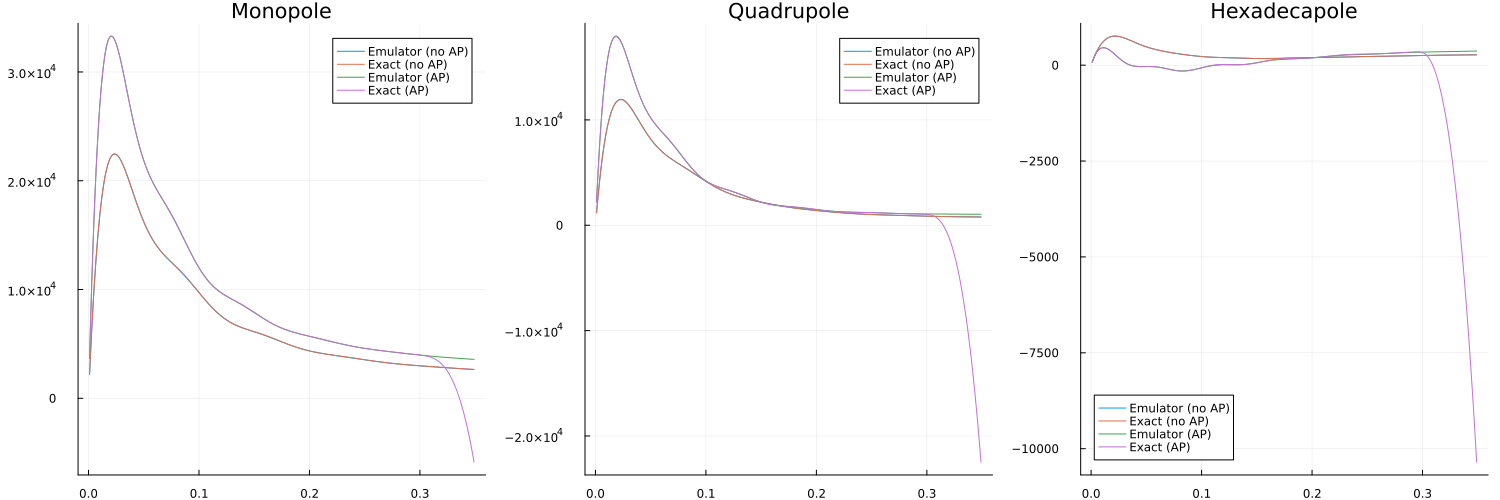

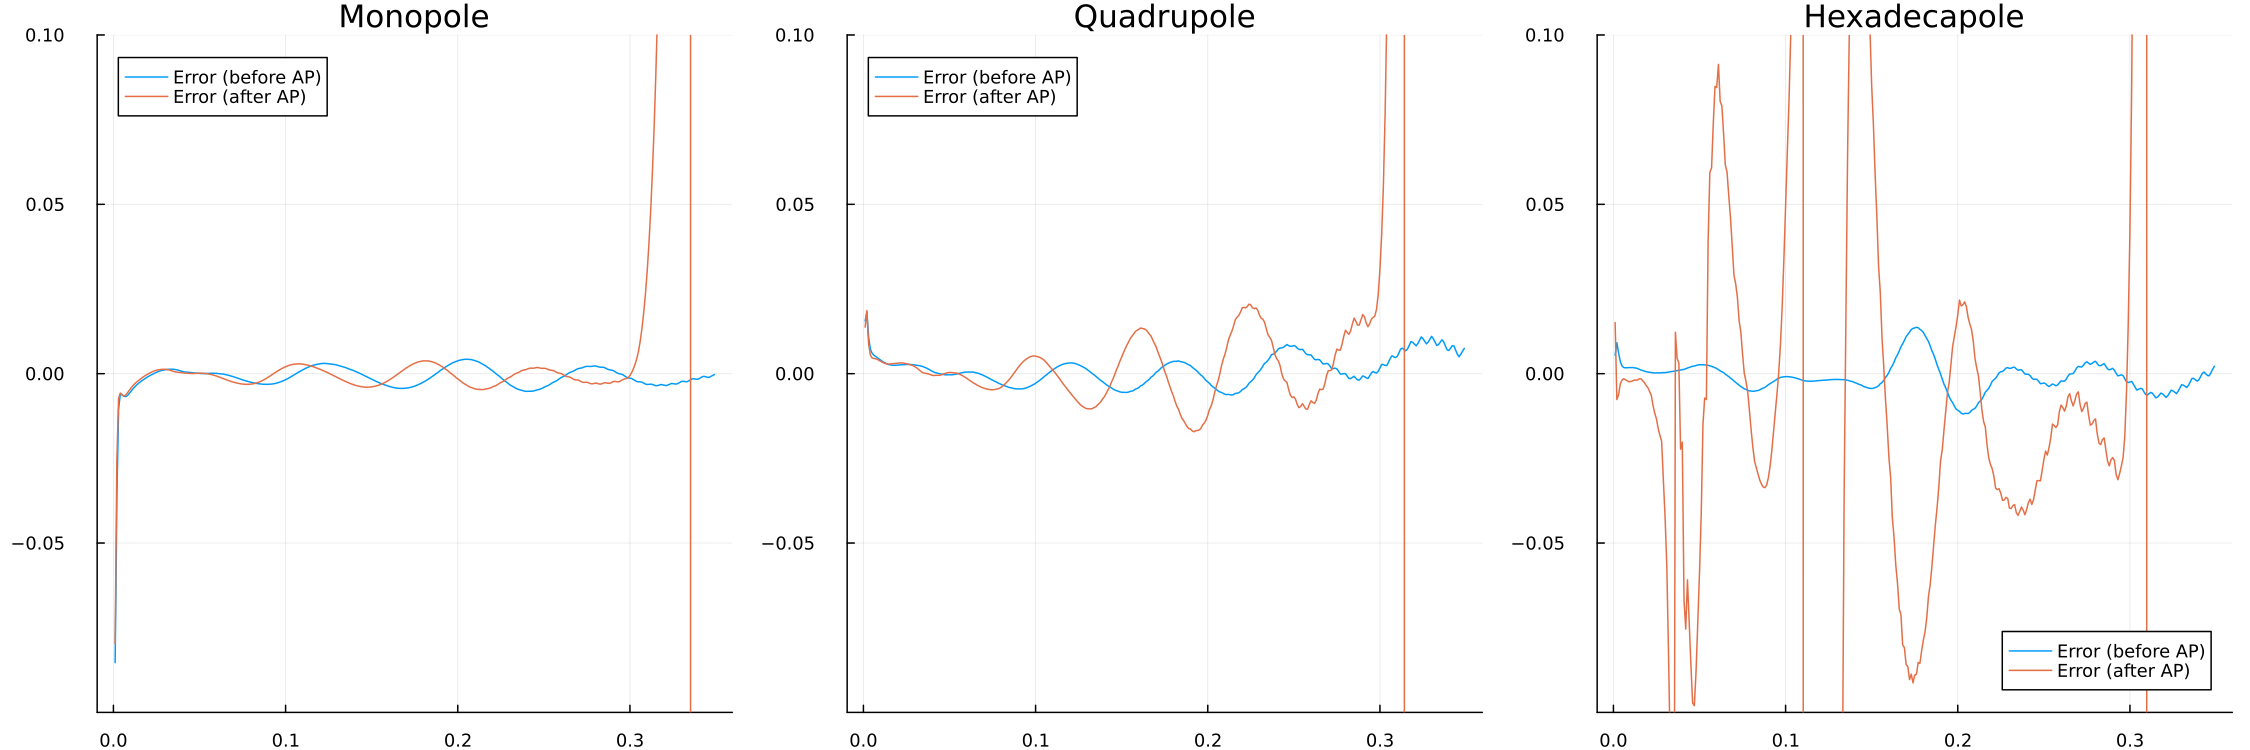

In [9]:
# Displays the various results

exact_noAP = vcat(P0, P2, P4)
emu_noAP = result_emu_noAP
exact_AP = vcat(P0_AP, P2_AP, P4_AP)
emu_AP = result_emu_AP

# Plots the monopole, quadrupole and hexadecapole for all four scenarios and overlays
p0 = plot(desi_kin, emu_noAP[1:349], label="Emulator (no AP)", title="Monopole")
plot!(desi_kin, exact_noAP[1:349], label="Exact (no AP)")
plot!(desi_kin, emu_AP[1:349], label="Emulator (AP)")
plot!(desi_kin, exact_AP[1:349], label="Exact (AP)")

p2 = plot(desi_kin, emu_noAP[350:350+348], label="Emulator (no AP)", title="Quadrupole")
plot!(desi_kin, exact_noAP[350:350+348], label="Exact (no AP)")
plot!(desi_kin, emu_AP[350:350+348], label="Emulator (AP)")
plot!(desi_kin, exact_AP[350:350+348], label="Exact (AP)")

p4 = plot(desi_kin, emu_noAP[699:699+348], label="Emulator (no AP)", title="Hexadecapole")
plot!(desi_kin, exact_noAP[699:699+348], label="Exact (no AP)")
plot!(desi_kin, emu_AP[699:699+348], label="Emulator (AP)")
plot!(desi_kin, exact_AP[699:699+348], label="Exact (AP)")

p024 = plot(p0, p2, p4, layout=(1,3), size=(1500, 500))
display(p024)


# Plots the relative percentage error 
p0_err = plot(desi_kin, (emu_noAP[1:349] .- exact_noAP[1:349]) ./ exact_noAP[1:349], label="Error (before AP)", dpi=150, ylim=(-0.1, 0.1), title="Monopole")
plot!(desi_kin, (emu_AP[1:349] .- exact_AP[1:349]) ./ exact_AP[1:349], label="Error (after AP)")

p2_err = plot(desi_kin, (emu_noAP[350:350+348] .- exact_noAP[350:350+348]) ./ exact_noAP[350:350+348], label="Error (before AP)", dpi=150, ylim=(-0.1, 0.1), title="Quadrupole")
plot!(desi_kin, (emu_AP[350:350+348] .- exact_AP[350:350+348]) ./ exact_AP[350:350+348], label="Error (after AP)")

p4_err = plot(desi_kin, (emu_noAP[699:699+348] .- exact_noAP[699:699+348]) ./ exact_noAP[699:699+348], label="Error (before AP)", dpi=150, ylim=(-0.1, 0.1), title="Hexadecapole")
plot!(desi_kin, (emu_AP[699:699+348] .- exact_AP[699:699+348]) ./ exact_AP[699:699+348], label="Error (after AP)")


p024_err = plot(p0_err, p2_err, p4_err, layout=(1,3), size=(1500, 500))
display(p024_err)